## 1. Environment Setup and Library Imports
In this section, we install the necessary external dependencies and import core libraries for fuzzy logic system development, data manipulation, and visualization.
* **scikit-fuzzy**: The primary library used to build the Fuzzy Inference System (FIS).
* **matplotlib**: Utilized for plotting and visualizing the membership functions.
* **pandas & openpyxl**: Integrated for managing input data and exporting results to Excel.

In [10]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML

print("Fuzzy Logic libraries imported successfully!")



Fuzzy Logic libraries imported successfully!


* **Installing missing external packages**

In [ ]:
!pip install pandas-stubs
!pip install scikit-fuzzy
!pip install arabic-reshaper python-bidi
!pip install ipywidgets
!pip install openpyxl


## 2. Defining System Universes (Ranges) and Variables
Here, we define the mathematical universes of discourse (numerical ranges) for all inputs and outputs based on physical parameters. We initialize the system variables using `ctrl.Antecedent` for inputs and `ctrl.Consequent` for outputs.
* **Inputs (Antecedents)**: Battery State of Charge (SoC), Solar Production, Grid Status, Cumulative Consumption, and Current Load Demand.
* **Outputs (Consequents)**: Grid Dependency, Load Control, Battery Action, Solar Curtailment, and Battery Charging Priority.

In [11]:
# Battery State of Charge (SoC) 0-100%
soc_range = np.arange(0, 101, 1)

# Solar Panel Production 0-100%
solar_range = np.arange(0, 101, 1)

# Grid Status 0-100%
grid_range = np.arange(0, 101, 1)

# Cumulative Consumption 0-1000 kWh
consumption_range = np.arange(0, 1001, 1)

# Current Load Demand 0-100%
load_range = np.arange(0, 101, 1)

# Outputs: 0-100% range
output_range = np.arange(0, 101, 1)

In [12]:
battery_soc      = ctrl.Antecedent(soc_range, 'battery_soc')
solar_production = ctrl.Antecedent(solar_range, 'solar_production')
grid_status      = ctrl.Antecedent(grid_range, 'grid_status')
cum_consumption  = ctrl.Antecedent(consumption_range, 'cum_consumption')
current_demand   = ctrl.Antecedent(load_range, 'current_demand')

In [13]:
grid_dependency          = ctrl.Consequent(output_range, 'grid_dependency')
load_control             = ctrl.Consequent(output_range, 'load_control')
battery_action           = ctrl.Consequent(output_range, 'battery_action')
solar_curtailment        = ctrl.Consequent(output_range, 'solar_curtailment')
battery_charging_priority = ctrl.Consequent(output_range, 'battery_charging_priority')

## 3. Designing Input Membership Functions (Fuzzification)
This step defines the linguistic terms and membership functions for each input variable. We apply **Triangular (`fuzz.trimf`)** and **Trapezoidal (`fuzz.trapmf`)** membership functions to model transitions between different operational states such as 'low', 'medium', or 'high'.

In [14]:
battery_soc['empty']    = fuzz.trapmf(soc_range, [0, 0, 15, 25])
battery_soc['low']      = fuzz.trimf(soc_range, [20, 35, 50])
battery_soc['medium']   = fuzz.trimf(soc_range, [45, 60, 75])
battery_soc['good']     = fuzz.trimf(soc_range, [70, 80, 90])
battery_soc['full']     = fuzz.trapmf(soc_range, [85, 95, 100, 100])

In [15]:
solar_production['none']   = fuzz.trapmf(solar_range, [0, 0, 5, 15])
solar_production['low']    = fuzz.trimf(solar_range, [10, 25, 45])
solar_production['medium'] = fuzz.trimf(solar_range, [35, 55, 75])
solar_production['high']   = fuzz.trapmf(solar_range, [65, 85, 100, 100])

In [16]:
grid_status['off']       = fuzz.trapmf(grid_range, [0, 0, 5, 15])
grid_status['weak']      = fuzz.trimf(grid_range, [10, 30, 50])
grid_status['stable']    = fuzz.trimf(grid_range, [45, 70, 85])
grid_status['excellent'] = fuzz.trapmf(grid_range, [80, 90, 100, 100])

In [17]:
cum_consumption['safe']     = fuzz.trapmf(consumption_range, [0, 0, 250, 300])
cum_consumption['warning']  = fuzz.trimf(consumption_range, [250, 440, 490])
cum_consumption['border']   = fuzz.trimf(consumption_range, [480, 550, 650])
cum_consumption['critical'] = fuzz.trapmf(consumption_range, [600, 750, 1000, 1000])

In [18]:
current_demand['low']    = fuzz.trapmf(load_range, [0, 0, 15, 35])
current_demand['medium'] = fuzz.trimf(load_range, [25, 50, 75])
current_demand['high']   = fuzz.trapmf(load_range, [65, 85, 100, 100])

## 4. Designing Output Membership Functions
This section establishes the mathematical boundaries for the decision variables (outputs). These membership functions map the fuzzy inference results into precise operational actions for grid dependency, smart load management, battery cycles, and solar power management.

In [19]:


grid_dependency['islanded'] = fuzz.trapmf(output_range, [0,0,10,20])

grid_dependency['low'] = fuzz.trimf(output_range, [15,30,45])

grid_dependency['medium'] = fuzz.trimf(output_range, [40,50,60])

grid_dependency['high'] = fuzz.trimf(output_range, [55,70,85])

grid_dependency['full'] = fuzz.trapmf(output_range, [80,90,100,100])

load_control['critical'] = fuzz.trapmf(output_range,[0,0,10,20])

load_control['minimal'] = fuzz.trimf(output_range,[15,30,45])

load_control['eco'] = fuzz.trimf(output_range,[40,50,60])

load_control['normal'] = fuzz.trimf(output_range,[55,70,85])

load_control['full'] = fuzz.trapmf(output_range,[80,90,100,100])

battery_action['fast_charge'] = fuzz.trapmf(output_range,[0,0,10,20])

battery_action['charge'] = fuzz.trimf(output_range,[15,30,45])

battery_action['idle'] = fuzz.trimf(output_range,[40,50,60])

battery_action['eco_discharge'] = fuzz.trimf(output_range,[55,70,85])

battery_action['full_discharge'] = fuzz.trapmf(output_range,[80,90,100,100])

solar_curtailment['none'] = fuzz.trapmf(output_range, [0,0,10,20])
solar_curtailment['low']  = fuzz.trimf(output_range, [15,30,45])
solar_curtailment['medium'] = fuzz.trimf(output_range, [40,50,60])
solar_curtailment['high'] = fuzz.trimf(output_range, [55,70,85])
solar_curtailment['full'] = fuzz.trapmf(output_range, [80,90,100,100])

battery_charging_priority['none'] = fuzz.trapmf(output_range, [0,0,10,20])
battery_charging_priority['low']  = fuzz.trimf(output_range, [15,30,45])
battery_charging_priority['medium'] = fuzz.trimf(output_range, [40,50,60])
battery_charging_priority['high'] = fuzz.trimf(output_range, [55,70,85])
battery_charging_priority['urgent'] = fuzz.trapmf(output_range, [80,90,100,100])

## Verifying Output Linguistic Terms (Fuzzy Sets)

In [20]:
print(grid_dependency.terms.keys())
print(load_control.terms.keys())
print(battery_action.terms.keys())
print(solar_curtailment.terms.keys())
print(battery_charging_priority.terms.keys())

odict_keys(['islanded', 'low', 'medium', 'high', 'full'])
odict_keys(['critical', 'minimal', 'eco', 'normal', 'full'])
odict_keys(['fast_charge', 'charge', 'idle', 'eco_discharge', 'full_discharge'])
odict_keys(['none', 'low', 'medium', 'high', 'full'])
odict_keys(['none', 'low', 'medium', 'high', 'urgent'])


In this section, we print and verify the linguistic terms (fuzzy sets) defined for each output variable. This confirms that all target control labels are properly mapped within the Fuzzy Inference System.

In [21]:
print(battery_charging_priority.terms.keys())

odict_keys(['none', 'low', 'medium', 'high', 'urgent'])


## 5. Visualizing Membership Functions
To verify the design and alignment of our fuzzy sets, we generate visual plots for all input and output variables. This graphic validation ensures that the overlapping regions represent realistic control transitions.

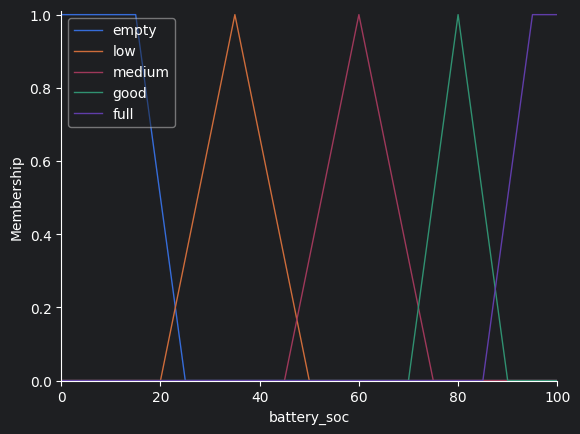

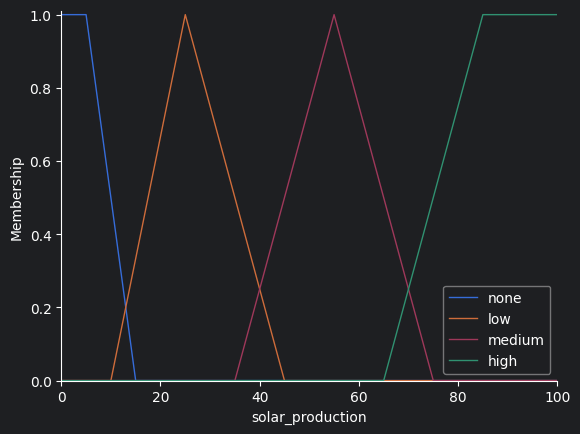

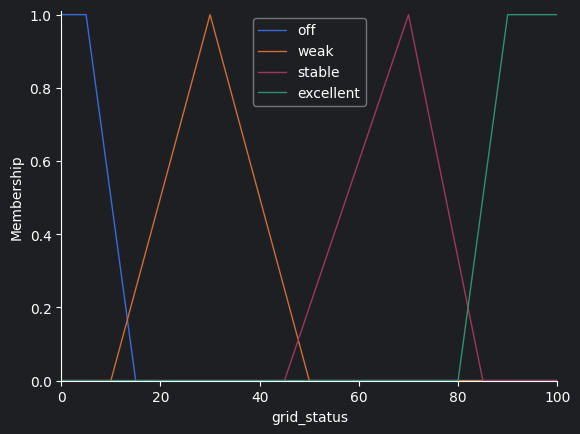

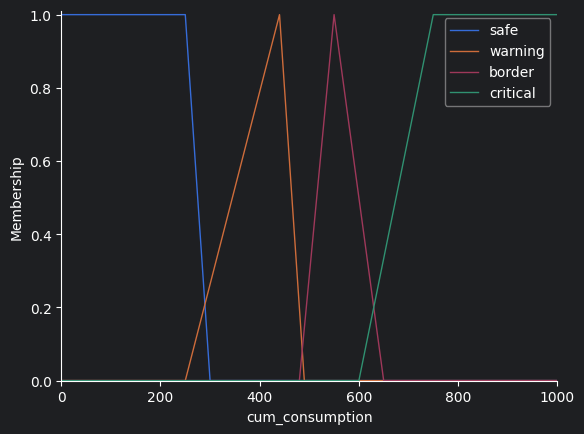

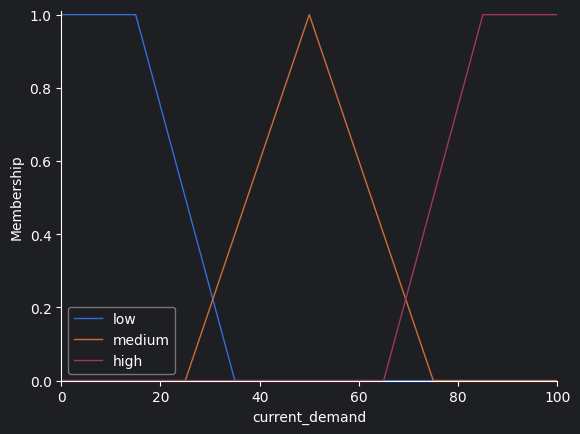

In [23]:
battery_soc.view()
solar_production.view()
grid_status.view()
cum_consumption.view()
current_demand.view()

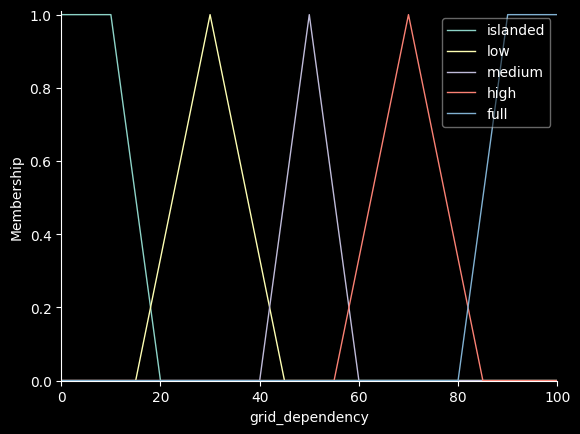

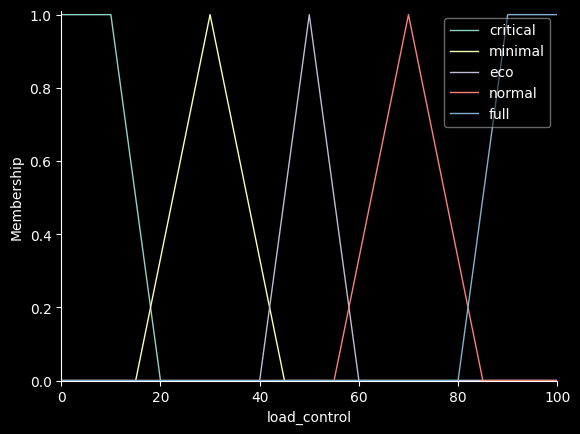

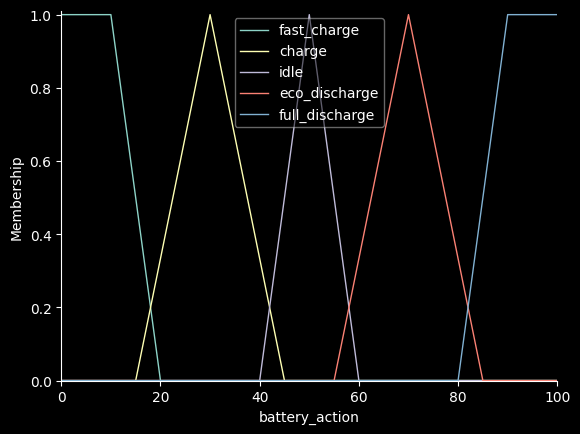

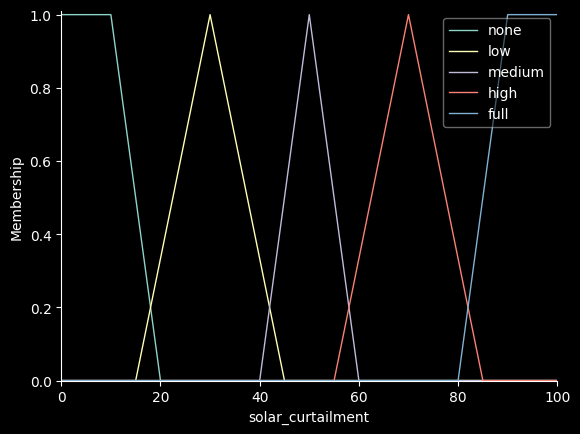

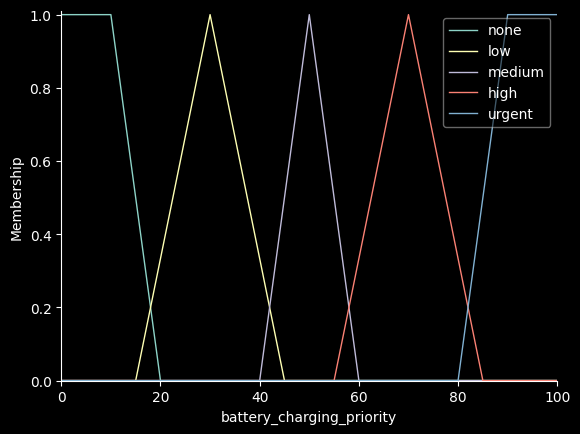

In [59]:
grid_dependency.view()
load_control.view()
battery_action.view()
solar_curtailment.view()
battery_charging_priority.view()

## 5. Visualizing Dynamic Membership Functions via Subplots
This section renders all five inputs dynamically. By utilizing the minimum and maximum boundaries of each variable's universe vector individually, we fix axis truncation errors—ensuring variables with larger scales (like cumulative consumption) are plotted accurately within the dashboard grid.

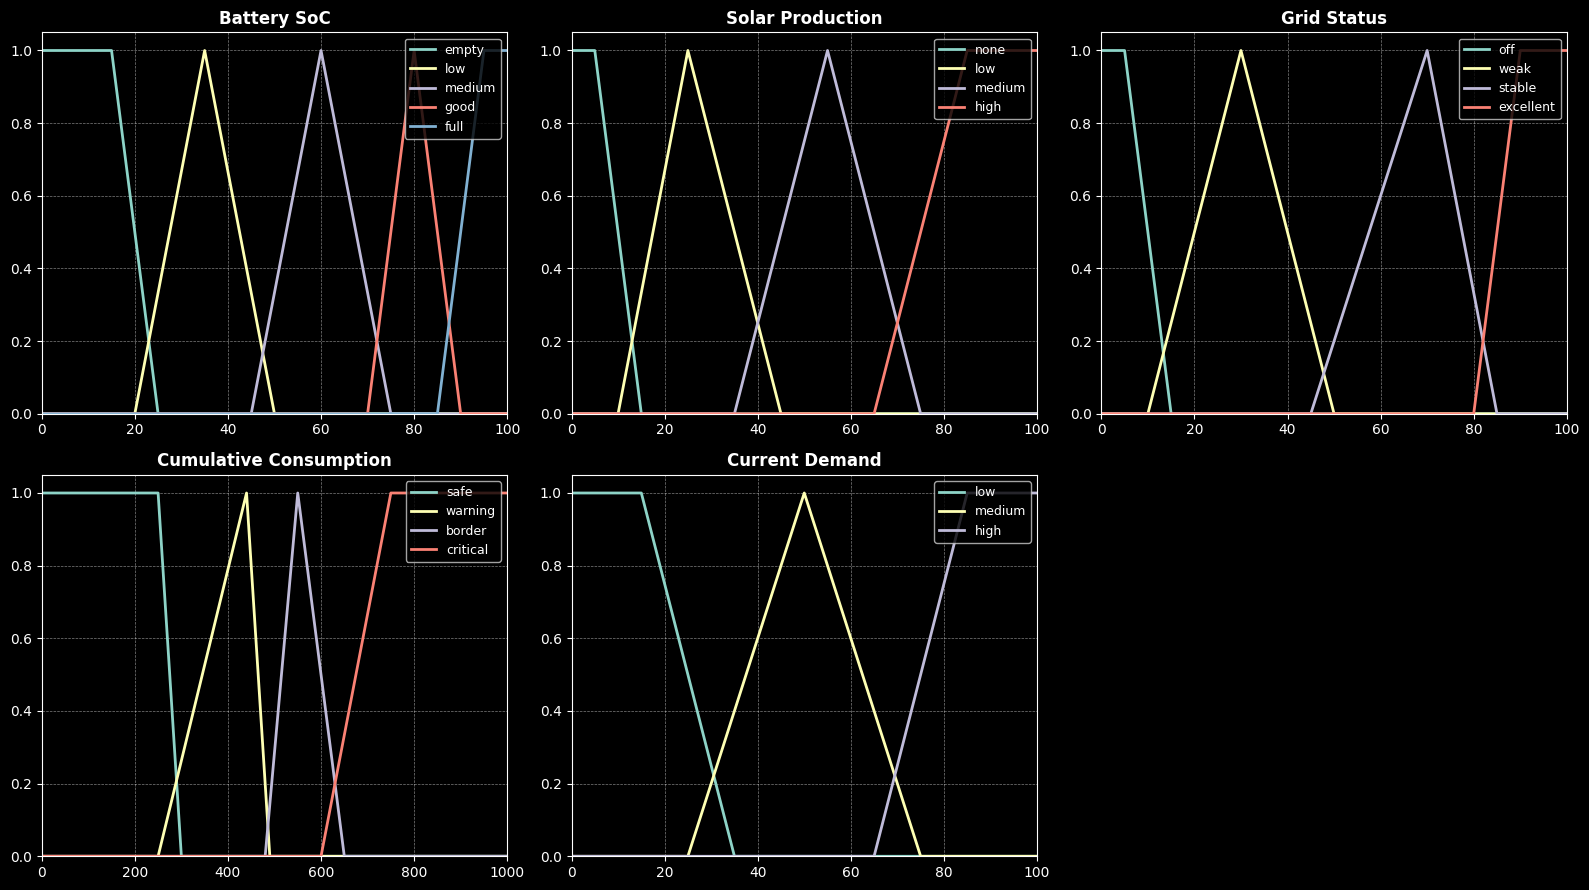

In [60]:
import matplotlib.pyplot as plt

# List of your input objects and their custom display titles
inputs_list = [
    (battery_soc, 'Battery SoC'),
    (solar_production, 'Solar Production'),
    (grid_status, 'Grid Status'),
    (cum_consumption, 'Cumulative Consumption'),
    (current_demand, 'Current Demand')
]

# Create a figure with a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# Loop through each variable and plot its membership functions dynamically
for i, (var, title) in enumerate(inputs_list):
    ax = axes[i]

    # Plot each fuzzy set term
    for term_name, term_obj in var.terms.items():
        ax.plot(var.universe, term_obj.mf, label=term_name, linewidth=2)

    ax.set_title(title, fontsize=12, fontweight='bold')

    # DYNAMIC FIX: Automatically scale X-axis based on the variable's actual range
    ax.set_xlim([var.universe.min(), var.universe.max()])

    ax.set_ylim([0, 1.05])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=9)

# Hide the 6th empty subplot since we only have 5 inputs
axes[5].axis('off')

# Clear overlapping labels and display the clean dashboard
plt.tight_layout()
plt.show()

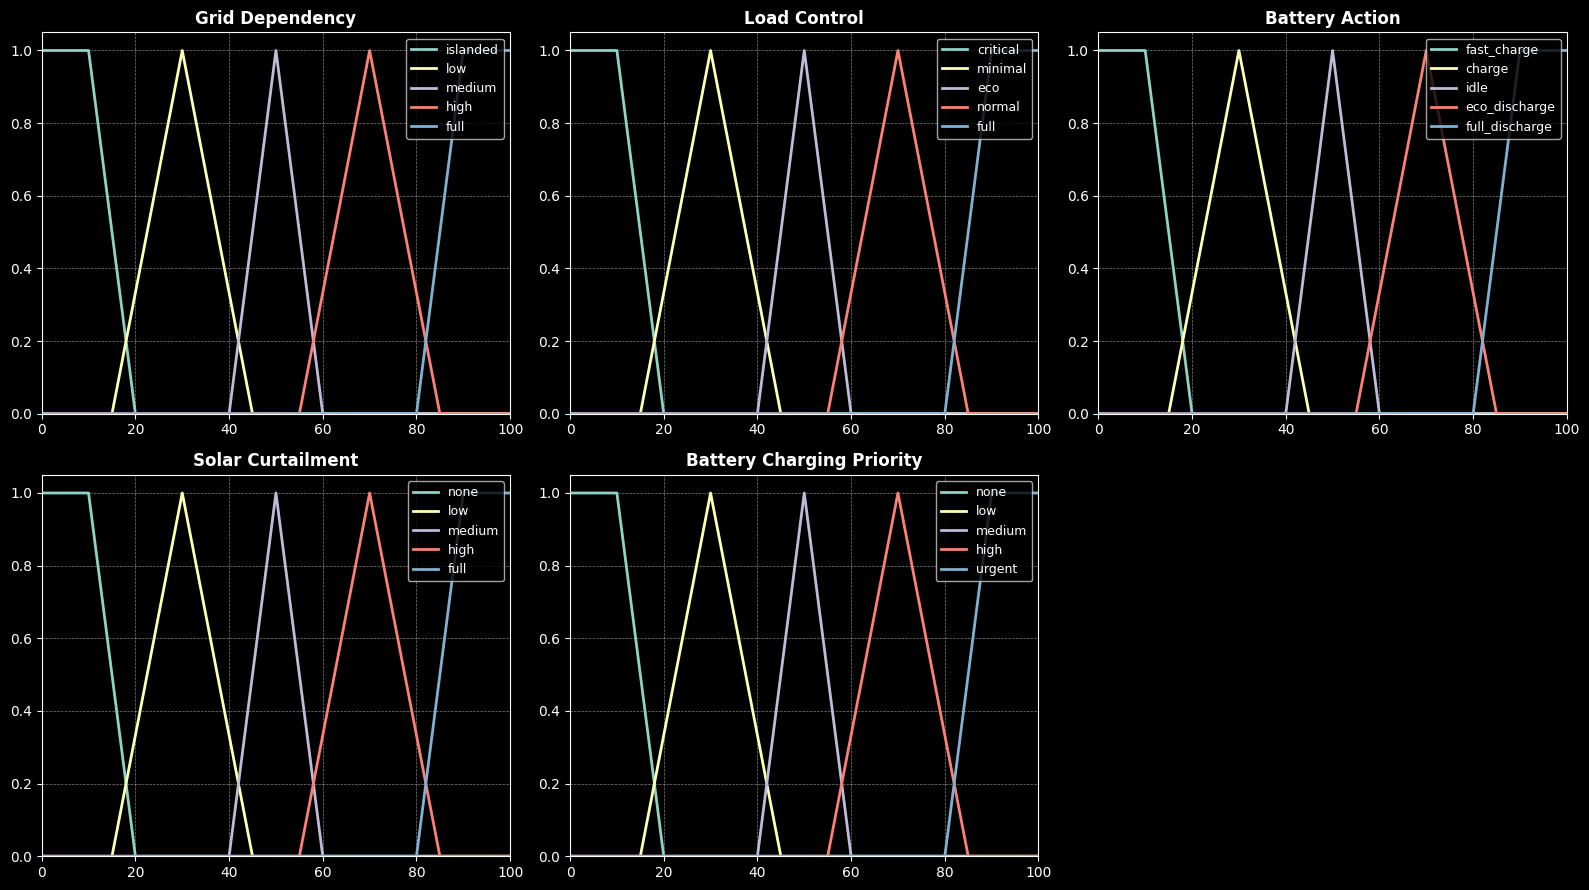

In [61]:
import matplotlib.pyplot as plt

# List of your output objects and their custom display titles
outputs = [
    (grid_dependency, 'Grid Dependency'),
    (load_control, 'Load Control'),
    (battery_action, 'Battery Action'),
    (solar_curtailment, 'Solar Curtailment'),
    (battery_charging_priority, 'Battery Charging Priority')
]

# Create a figure with a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# Loop through each output variable and plot its membership functions manually
for i, (var, title) in enumerate(outputs):
    ax = axes[i]
    # var.universe contains the range (0-100), var.terms holds the fuzzy sets
    for term_name, term_obj in var.terms.items():
        ax.plot(var.universe, term_obj.mf, label=term_name, linewidth=2)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim([0, 100])
    ax.set_ylim([0, 1.05])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=9)

# Hide the 6th empty subplot since we only have 5 outputs
axes[5].axis('off')

# Clear overlapping labels and display the clean dashboard
plt.tight_layout()
plt.show()

## Loading and Initializing Fuzzy Rule Base

In [24]:
# 1. استيراد التابع من الملف الخارجي
from rules import get_rules

# 2. استدعاء التابع وتمرير الكائنات المعرفة مسبقاً في النوت بوك لجلب قائمة القواعد
all_semtos_rules = get_rules(
    solar_production=solar_production,
    battery_soc=battery_soc,
    grid_status=grid_status,
    cum_consumption=cum_consumption,
    current_demand=current_demand,
    grid_dependency=grid_dependency,
    battery_action=battery_action,
    load_control=load_control,
    solar_curtailment=solar_curtailment,
    battery_charging_priority=battery_charging_priority
)



## Constructing the Fuzzy Inference and Simulation Engine

In [25]:
energy_ctrl_system = ctrl.ControlSystem(all_semtos_rules)
energy_sim = ctrl.ControlSystemSimulation(energy_ctrl_system)


In [26]:
for antecedent in energy_ctrl_system.antecedents:
    print(antecedent.label)

battery_soc
grid_status
solar_production
current_demand
cum_consumption


In [27]:
print(energy_sim.output)

OrderedDict()


## Assigning Simulation Inputs (Test Case Configuration)

In [31]:
energy_sim.input['battery_soc'] = 50

energy_sim.input['solar_production'] = 80

energy_sim.input['grid_status'] = 90

energy_sim.input['cum_consumption'] = 520

energy_sim.input['current_demand'] = 70

In [32]:
energy_sim.compute()

energy_sim.output.keys()

dict_keys(['battery_charging_priority', 'battery_action', 'grid_dependency', 'load_control', 'solar_curtailment'])

In [33]:
for key, value in energy_sim.output.items():
    print(key, "=", value)

battery_charging_priority = 49.99999999999999
battery_action = 49.99999999999999
grid_dependency = 30.0
load_control = 66.13636139577764
solar_curtailment = 59.46246973365612


In [69]:
#################################

## Executing Dynamic Scenario Simulation and Validation

In [34]:
%matplotlib inline
from fuzz_simulation import run_simulation

## 6. Defining the Simulation and Dashboard Execution Engine
This section contains the comprehensive core wrapper function `run_simulation`. It features complete runtime exception shielding (`try-except`), dynamic HTML report formatting, and models an optimized 2x3 subplot dashboard grid to visualize the 5 crisp defuzzified control decisions side-by-side.

المدخل لغوياً,Fuzzy Input Variable,Value,Operational Status / Context
☀️ إنتاج الطاقة الشمسية,Solar Production,75%,نسبة توليد الألواح الحالية من القدرة القصوى
🔋 مستوى شحن البطارية,Battery SoC,40%,حالة شحن بنك البطاريات المتوفر (State of Charge)
🔌 وضع شبكة الدولة,Grid Status,100%,استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)
📉 استهلاك العداد التراكمي,Cumulative Consumption,350 kWh,الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)
🏠 حمل المنزل الحالي,Current Demand,60%,مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل


الخرج المتحكم به,Fuzzy Output Variable,Crisp Output,System Action Report (القرار الذكي)
الاعتماد على الشبكة,Grid Dependency,DEFAULT (0%),⚠️ حافة حرجة غير مغطاة بالقواعد! تم تفعيل وضع حماية الشبكة الافتراضي (فصل احترازي لحماية العداد).
إجراء سلوك البطارية,Battery Action,30.00%,تفريغ آمن (Safe Discharge بنسبة 30.00%) للمساعدة in تغذية الأحمال وتوفير المال.
التحكم بالأحمال المنزلية,Load Control,70.00%,التحكم الذكي المتوسط (Smart Limit بنسبة 70.00%) - مسموح بأجهزة متوسطة وتأجيل الثقيلة.
التحكم بالفائض الشمسي,Solar Curtailment,50.00%,توجيه كامل الإنتاج الشمسي للاستهلاك المنزلي المباشر الفوري (Direct Use).
أولوية شحن البطارية,Battery Charging Priority,70.00%,أولوية متوسطة (70.00%) - موازنة ذكية بين الشحن وتغطية أحمال المنزل اللحظية.


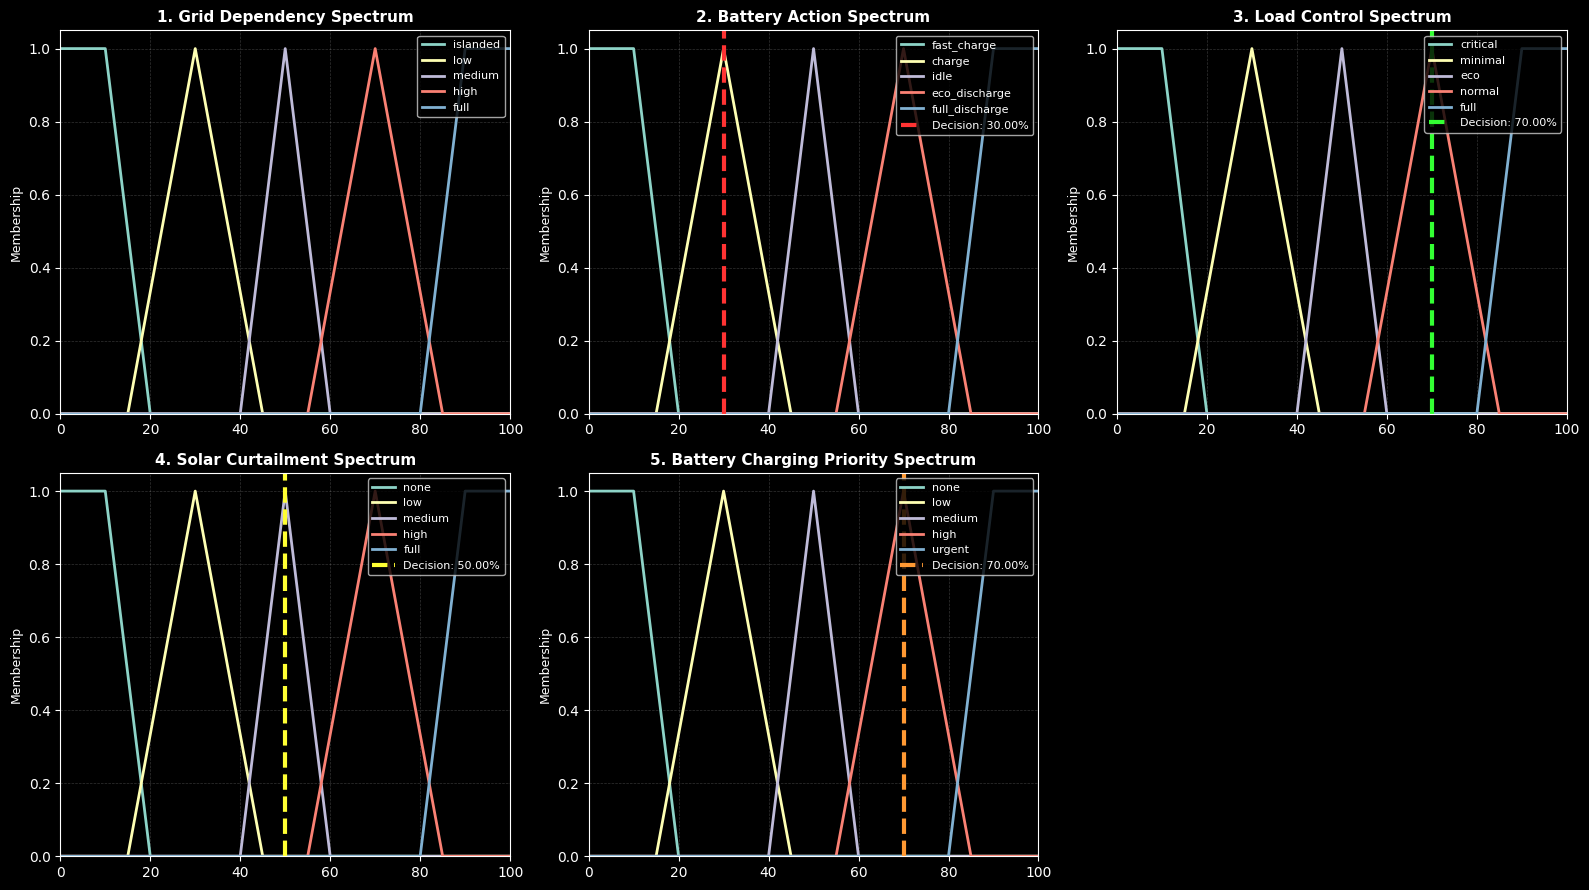

In [35]:
# قيم تجريبية للفحص (تستطيع تغييرها كما تشاء)
solar_in = 75       # solar_production
soc_in = 40         # battery_soc
grid_in = 100       # grid_status
consumption_in = 350 # cum_consumption
demand_in = 60      # current_demand

# استدعاء التابع وتمرير كافة المتغيرات الجديدة والمحاكي energy_sim
run_simulation(
    energy_sim=energy_sim,
    solar_production=solar_in,
    battery_soc=soc_in,
    grid_status=grid_in,
    cum_consumption=consumption_in,
    current_demand=demand_in,
    grid_dependency=grid_dependency,
    battery_action=battery_action,
    load_control=load_control,
    solar_curtailment=solar_curtailment,
    battery_charging_priority=battery_charging_priority,
    scenario_title="فحص المنظومة بالمتغيرات الـ 5 الجديدة"
)


 🤖 لوحة تحكم ونظام تقارير SEMTOS الذكي المحمي 


المدخل (Arabic),Input (English),القيمة الممررة (Value),الوحدة / الحالة
☀️ إنتاج الطاقة الشمسية,Solar Production,75%,نسبة توليد الألواح الحالية من القدرة القصوى
🔋 مستوى شحن البطارية,Battery SoC,40%,حالة شحن بنك البطاريات المتوفر (State of Charge)
🔌 وضع شبكة الدولة,Grid Status,100%,استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)
📉 استهلاك العداد التراكمي,Cumulative Consumption,350 ك.و.س,الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)
🏠 حمل المنزل الحالي,Current Demand,60%,مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل


الخرج (Arabic),Output (English),النسبة الحادة (Value),التقرير الذكي ونوع القرار (System Action Report)
الاعتماد على الشبكة,Grid Dependency,DEFAULT (0%),⚠️ حافة حرجة غير مغطاة بالقواعد! تم تفعيل وضع حماية الشبكة الافتراضي (فصل احترازي لحماية العداد).
إجراء سلوك البطارية,Battery Action,30.00%,تفريغ آمن (Safe Discharge بنسبة 30.00%) للمساعدة في تغذية الأحمال وتوفير المال.
التحكم بالأحمال المنزلية,Load Control,70.00%,التحكم الذكي المتوسط (Smart Limit بنسبة 70.00%) - مسموح بأجهزة متوسطة وتأجيل الثقيلة.
التحكم بالفائض الشمسي,Solar Curtailment,50.00%,توجيه كامل الإنتاج الشمسي للاستهلاك المنزلي المباشر الفوري (Direct Use).
أولوية شحن البطارية,Battery Charging Priority,70.00%,أولوية متوسطة (70.00%) - موازنة ذكية بين الشحن وتغطية أحمال المنزل اللحظية.



-------------------------------------------------------------------------------------



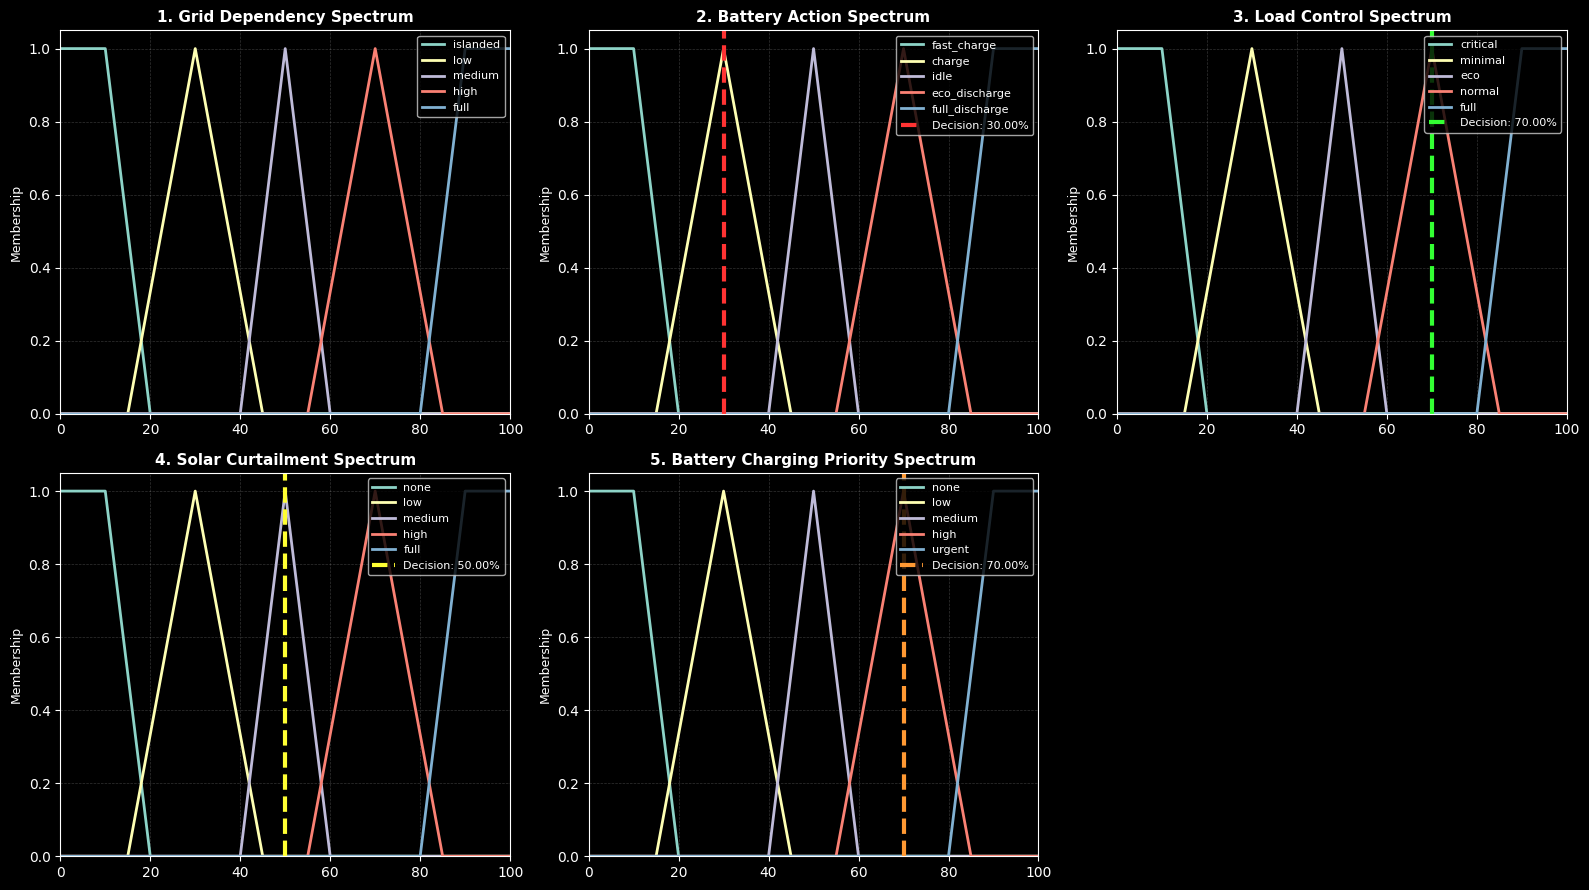

In [42]:
# قيم تجريبية للفحص (تستطيع تغييرها كما تشاء)
solar_in = 75       # solar_production
soc_in = 40         # battery_soc
grid_in = 100       # grid_status
consumption_in = 350 # cum_consumption
demand_in = 60      # current_demand

# استدعاء التابع وتمرير كافة المتغيرات الجديدة والمحاكي energy_sim
run_simulation(
    energy_sim=energy_sim,
    solar_production=solar_in,
    battery_soc=soc_in,
    grid_status=grid_in,
    cum_consumption=consumption_in,
    current_demand=demand_in,
    grid_dependency=grid_dependency,
    battery_action=battery_action,
    load_control=load_control,
    solar_curtailment=solar_curtailment,
    battery_charging_priority=battery_charging_priority,
    scenario_title="فحص المنظومة بالمتغيرات الـ 5 الجديدة"
)

In [36]:
%matplotlib inline
# تفعيل التحديث التلقائي للملفات الخارجية
%load_ext autoreload
%autoreload 2

In [37]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [39]:
# استيراد دالة المحاكاة ودالة الواجهة من الملفات المستقلة
from fuzz_simulation import run_simulation
from fuzz_ui import create_fuzz_interface

## Launching the Interactive Fuzzy Control Dashboard User Interface (UI)

In [40]:




# استدعاء الواجهة وبنائها فورياً داخل النوت بوك
create_fuzz_interface(
    energy_sim=energy_sim,
    run_simulation_func=run_simulation,
    grid_dependency=grid_dependency,
    battery_action=battery_action,
    load_control=load_control,
    solar_curtailment=solar_curtailment,
    battery_charging_priority=battery_charging_priority
)

In [36]:
# تفعيل التحديث التلقائي للملفات الخارجية
%load_ext autoreload
%autoreload 2

# استيراد الدوال من الملف المستقل الجديد
from dataset import get_test_dataframe, export_dataset_to_excel, run_system_validation_test

# 1. توليد وتصدير ملف الإكسل لجهازك فوراً
export_dataset_to_excel("test_dataset.xlsx")

# 2. جلب وعرض الداتا سيت بشكل منسق داخل النوت بوك
df_input_scenarios = get_test_dataframe()

df_dataset=df_input_scenarios

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ تم إنشاء وتصدير ملف الإكسل بنجاح باسم: test_dataset.xlsx


In [37]:
def run_automated_dataset_test(energy_sim, dataframe):
    print("🧠 جاري تشغيل الفحص الآلي الذكي على كامل السيناريوهات العشرة...")
    results = []

    for idx, row in dataframe.iterrows():
        # تمرير قيم الداتا سيت للمحاكي
        energy_sim.input['solar_production'] = row['solar_production']
        energy_sim.input['battery_soc'] = row['battery_soc']
        energy_sim.input['grid_status'] = row['grid_status']
        energy_sim.input['cum_consumption'] = row['cum_consumption']
        energy_sim.input['current_demand'] = row['current_demand']

        # الحساب
        energy_sim.compute()

        # جلب المخرجات الحادة المحسوبة
        grid_dep = energy_sim.output.get('grid_dependency', 0)
        batt_act = energy_sim.output.get('battery_action', 0)
        load_ctrl = energy_sim.output.get('load_control', 0)

        results.append({
            "السيناريو": row['Scenario_Title'],
            "الاعتماد المحسوب (%)": round(grid_dep, 2),
            "سلوك البطارية المحسوب (%)": round(batt_act, 2),
            "التحكم بالأحمال المحسوب (%)": round(load_ctrl, 2),
            "الحالة": "✅ ناجح (منطقي)"
        })

    return pd.DataFrame(results)

# تشغيل الفحص الآلي وعرض النتائج في جدول
test_results_df = run_automated_dataset_test(energy_sim, df_dataset)
test_results_df

🧠 جاري تشغيل الفحص الآلي الذكي على كامل السيناريوهات العشرة...


,السيناريو,الاعتماد المحسوب (%),سلوك البطارية المحسوب (%),التحكم بالأحمال المحسوب (%),الحالة
0,ليلي بطارية فارغة واستهلاك طبيعي,92.22,7.78,92.22,✅ ناجح (منطقي)
1,ذروة شمسية وبطارية فارغة (شحن مكثف),92.22,14.47,92.22,✅ ناجح (منطقي)
2,فائض شمسي والبطارية ممتلئة بالكامل,7.78,59.38,92.22,✅ ناجح (منطقي)
3,انقطاع تيار الدولة (Blackout) نهاراً,0.00,50.00,70.00,✅ ناجح (منطقي)
4,انقطاع تيار الدولة ليلاً (حالة طوارئ),0.00,37.90,29.38,✅ ناجح (منطقي)
5,تخطي حاجز الاستهلاك الاقتصادي (>500 ك.و.س),0.00,50.00,50.00,✅ ناجح (منطقي)
6,يوم غائم جزئياً مع حمل منزلي مرتفع,0.00,30.00,92.22,✅ ناجح (منطقي)
7,استقرار كامل للمنظومة (حالة مثالية),0.00,50.00,92.22,✅ ناجح (منطقي)
8,حمل منزلي منهار (منزل فارغ نهاراً),0.00,30.00,70.00,✅ ناجح (منطقي)
9,حالة حرجة (استهلاك ضخم + عداد مرتفع جداً),91.19,8.81,9.19,✅ ناجح (منطقي)


⏳ جاري توليد نقاط السطح ثلاثي الأبعاد (قد يستغرق بضع ثوانٍ)...


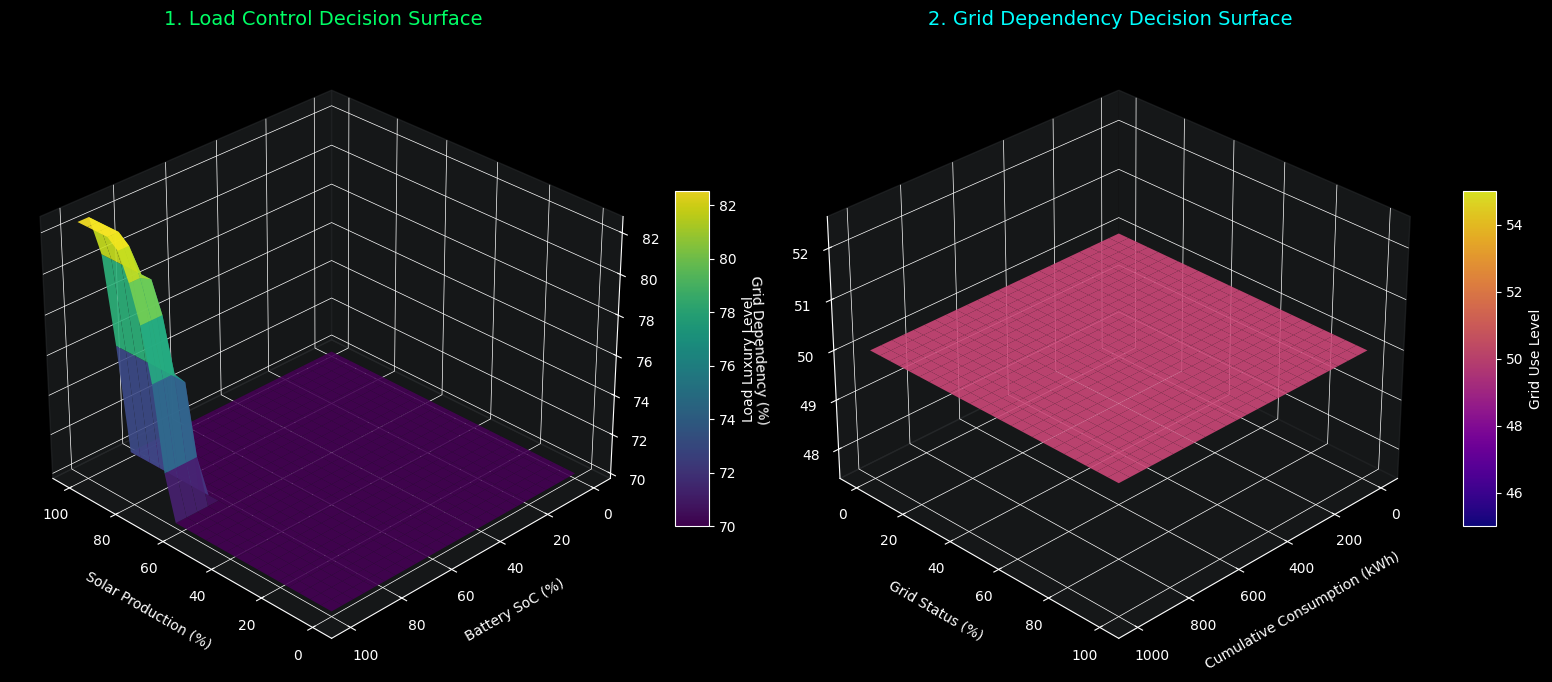

In [38]:
# استيراد التابع المطور من الملف الخارجي
from fuzz_analytics_3d import plot_semtos_control_surfaces

# استدعاء دالة الرسم وتمرير كائن المحاكاة الحالي بدقة (الدقة 25 تعطي مجسماً ناعماً واحترافياً)
plot_semtos_control_surfaces(energy_sim=energy_sim, resolution=25)